# Preprocess the divided *Train* and *Test* Dataset

### GPU Availability Test

In [1]:
import tensorflow as tf
print("\n\nNum GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-08-22 23:11:47.274857: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-22 23:11:47.289920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755904307.303788   25038 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755904307.307487   25038 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-22 23:11:47.322697: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr



Num GPUs Available:  1


## Dataset

In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv("Prepared-Data/train-data.csv")
train_df

,Text,Ham,Spam
0,Time n Smile r the two crucial things in our l...,1,0
1,Last chance to get 500 BONUS POINTS on shoppin...,0,1
2,IM GONNA MISS U SO MUCH,1,0
3,Alert! Your Vi Unlimited pack EXPIRES in 6 Day...,0,1
4,Ur balance is now å£500. Ur next question is: ...,0,1
...,...,...,...
10678,"Hmm ok, i'll stay for like an hour cos my eye ...",1,0
10679,Now you can transfer your account balance to y...,0,1
10680,"What are you doing in langport? Sorry, but I'l...",1,0
10681,Magic be believe in yourself If you can do tha...,0,1


## Preprocessing

In [4]:
from tensorflow.keras.layers import TextVectorization

In [5]:
train_df.columns

Index(['Text', 'Ham', 'Spam'], dtype='object')

In [6]:
# Ham and Spam array values
op_vals = train_df[train_df.columns[1:]].values
op_vals

array([[1, 0],
       [0, 1],
       [1, 0],
       ...,
       [1, 0],
       [0, 1],
       [1, 0]])

In [7]:
X = train_df["Text"]
y = op_vals

In [8]:
train_df["Text"].iloc[4245]

'Y Ì_ wan to go there? C doctor?'

In [9]:
# Getting the maximum vocab length
words_list = " ".join(train_df["Text"]).split()
vocab = set(words_list)
print("Vocab Length: ", len(vocab))

Vocab Length:  37973


In [10]:
# So assigning around 38000 features (greater than vocab)
MAX_FEATURES = 38000
MAX_LEN = 1070

In [11]:
vectorizer = TextVectorization(
    max_tokens = MAX_FEATURES,
    output_mode = 'int',
    output_sequence_length= MAX_LEN,
)

I0000 00:00:1755904321.478571   25038 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
# Teach vectorizer our vocabulary
vectorizer.adapt(X.values)

In [13]:
len(vectorizer.get_vocabulary())

26581

In [14]:
vectorizer("This notebook is written by manas")

<tf.Tensor: shape=(1070,), dtype=int64, numpy=array([  33, 8661,   15, ...,    0,    0,    0])>

In [15]:
vectorized_text = vectorizer(X.values)
vectorized_text

<tf.Tensor: shape=(10683, 1070), dtype=int64, numpy=
array([[  79,  169,  606, ...,    0,    0,    0],
       [ 182,  425,    2, ...,    0,    0,    0],
       [  60,  476,  205, ...,    0,    0,    0],
       ...,
       [  82,   42,    4, ...,    0,    0,    0],
       [3896,    8,  836, ...,    0,    0,    0],
       [ 144,    4,  121, ...,    0,    0,    0]])>

In [16]:
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(32)
dataset = dataset.prefetch(8) # helps prevent bottle necks

In [17]:
batch_X, batch_y = dataset.as_numpy_iterator().next()
dataset.as_numpy_iterator().next()

(array([[ 1384,  6747,   563, ...,     0,     0,     0],
        [    3,    71,   122, ...,     0,     0,     0],
        [ 2963,    40,    16, ...,     0,     0,     0],
        ...,
        [11602,     0,     0, ...,     0,     0,     0],
        [   60,    11, 14135, ...,     0,     0,     0],
        [ 1198,  1958,   236, ...,     0,     0,     0]]),
 array([[0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1]]))

In [18]:
# Dividing for train and validation
train = dataset.take(int(len(dataset)*.9))
validation = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

## Building Bidirectional LSTM

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Embedding, Dense

In [20]:
model = Sequential()

# Embedding layer
model.add(Embedding(MAX_FEATURES+1, 32))

# TanH function works better with GPU
model.add(Bidirectional(LSTM(32, activation='tanh')))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

# OUTPUT layer
model.add(Dense(2, activation='sigmoid'))

In [21]:
model.compile(loss="BinaryCrossentropy", optimizer='Adam')

In [22]:
history = model.fit(train, epochs=20, validation_data=validation)

Epoch 1/20


I0000 00:00:1755904334.033050   28846 cuda_dnn.cc:529] Loaded cuDNN version 90300


300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - loss: 0.3121 - val_loss: 0.0516
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - loss: 0.0281 - val_loss: 0.0156
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - loss: 0.0160 - val_loss: 0.0072
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - loss: 0.0049 - val_loss: 4.9313e-04
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - loss: 0.0033 - val_loss: 0.0013
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 125ms/step - loss: 0.0027 - val_loss: 1.5993e-04
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 128ms/step - loss: 0.0041 - val_loss: 0.0015
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - loss: 0.0016 - val_loss: 6.0908e-05
Epoch 9/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - loss: 1.6510e-04 - val_loss: 4.6890e-06
Epoch 10/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - loss: 5.5134e-06 - val_loss: 7.0683e-06
Epoch 11/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - loss: 2.6309e-06 - val_loss: 1.315

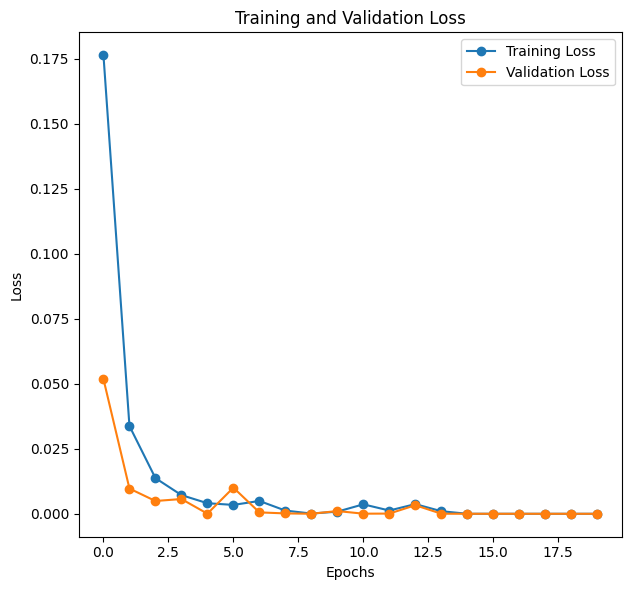

In [ ]:
import matplotlib.pyplot as plt
history_dict = history.history

# Extract values
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']

# If you have additional metrics (like accuracy)
if 'accuracy' in history_dict:
    train_accuracy = history_dict['accuracy']
    val_accuracy = history_dict['val_accuracy']

# Plot Training and Validation Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Accuracy (if available)
if 'accuracy' in history_dict:
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracy, label='Training Accuracy', marker='o')
    plt.plot(val_accuracy, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

## Saving Vectorizer model and Prediction Model

In [ ]:
tf.keras.models.save_model(vectorizer, "Models/Vectorizer-Models/spam_ham_text_vectorizer_2.keras")


model.save("Models/Predictive-Models/spam_ham_BiLstm_2.keras")
model.save_weights("Models/Predictive-Models/spam_ham_BiLstm_2.weights.h5")

 Preprocessing and Training Done!!

## Small test

In [ ]:
import numpy as np

In [ ]:
def predict_text_sms(sms: str) -> str:
    result_map = {
        0: "Ham",
        1: "Spam"
    }
    vec = vectorizer(sms)
    pred = model.predict(np.expand_dims(vec, 0))
    
    return result_map[np.argmax(pred)] 

In [ ]:
predict_text_sms("Hey there how are you??")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


'Ham'

In [ ]:
predict_text_sms("You have won 2 lakh rupees lottery!!! to claim it whatsapp on this number!!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


'Spam'

Data Preprocessing and Model Building is Done!!